##### Load all 5 country cleaned CSV files and combine into one DataFrame

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']

df_list = []
for country in countries:
    try:
        df = pd.read_csv(f"../data/{country}_clean.csv")
        df['Country'] = country.title()
        df_list.append(df)
        print(f"Loaded {country}: {df.shape[0]} rows")
    except FileNotFoundError:
        print(f"Warning: {country}_clean.csv not found")


combined = pd.concat(df_list, ignore_index=True)
print(f"\nCombined shape: {combined.shape}")
print(f"Countries: {combined['Country'].unique()}")

Loaded ethiopia: 4108 rows
Loaded kenya: 4108 rows
Loaded nigeria: 4108 rows
Loaded sudan: 4108 rows
Loaded tanzania: 4108 rows

Combined shape: (20540, 15)
Countries: <StringArray>
['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']
Length: 5, dtype: str


##### Monthly average temperature trend for all 5 countries (2015-2026)

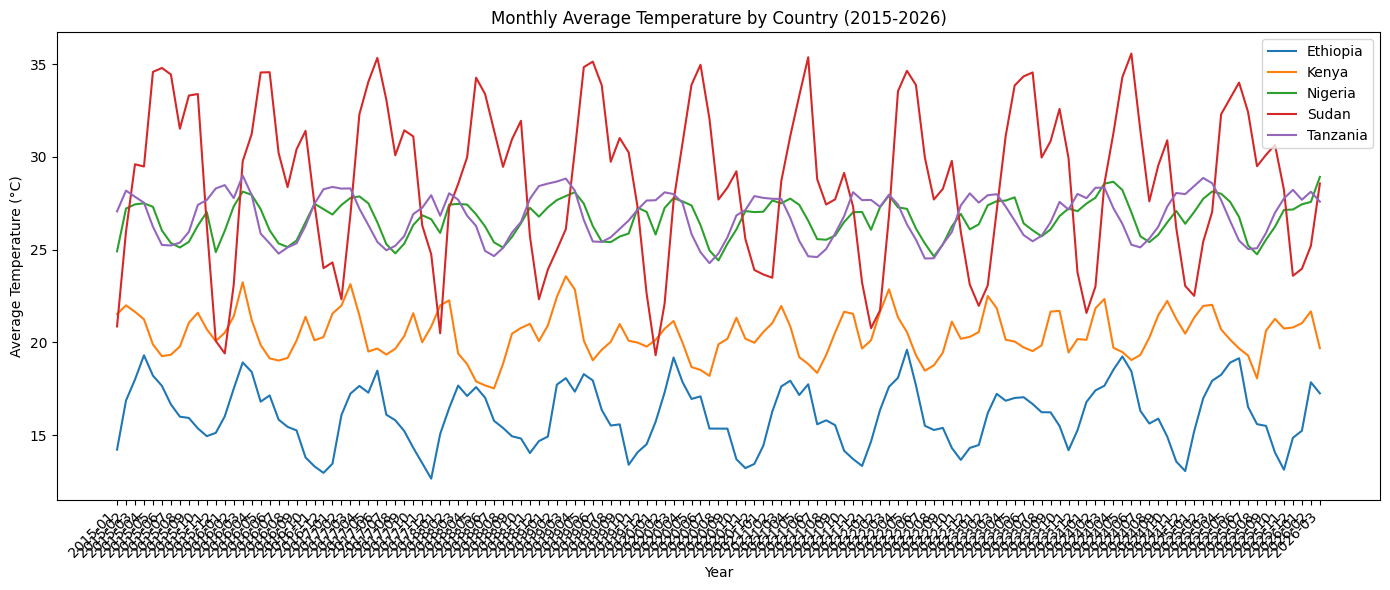

In [2]:
combined['Date'] = pd.to_datetime(combined['Date'])

combined['YearMonth'] = combined['Date'].dt.to_period('M')

# Calculate monthly average temperature per country
monthly_temp = combined.groupby(['Country', 'YearMonth'])['T2M'].mean().reset_index()
monthly_temp['YearMonth_str'] = monthly_temp['YearMonth'].astype(str)

plt.figure(figsize=(14, 6))
for country in monthly_temp['Country'].unique():
    country_data = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(country_data['YearMonth_str'], country_data['T2M'], label=country, linewidth=1.5)

plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.title('Monthly Average Temperature by Country (2015-2026)')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Summary statistics for temperature by country

In [3]:
temp_summary = combined.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
temp_summary.columns = ['Mean (°C)', 'Median (°C)', 'Std Dev (°C)']
print("Temperature Summary by Country:")
print(temp_summary)

Temperature Summary by Country:
          Mean (°C)  Median (°C)  Std Dev (°C)
Country                                       
Ethiopia      16.07        16.04          1.90
Kenya         20.43        20.36          1.44
Nigeria       26.66        26.82          1.12
Sudan         28.76        29.16          4.68
Tanzania      26.80        26.99          1.33


Sudan is the hottest country (28.8°C). Ethiopia is the coldest (16.1°C). 
Temperatures range from cool in Ethiopia to very hot in Sudan.

##### Precipitation distribution comparison across countries

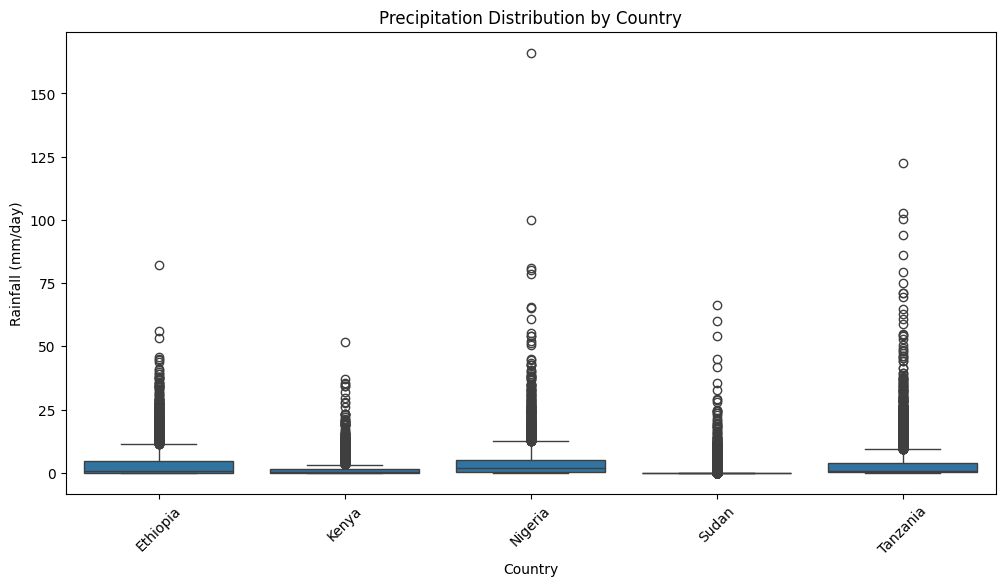

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined, x='Country', y='PRECTOTCORR')
plt.title('Precipitation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Rainfall (mm/day)')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Precipitation summary table
precip_summary = combined.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
precip_summary.columns = ['Mean (mm)', 'Median (mm)', 'Std Dev (mm)']
print("Precipitation Summary by Country:")
print(precip_summary)

Precipitation Summary by Country:
          Mean (mm)  Median (mm)  Std Dev (mm)
Country                                       
Ethiopia       3.63         0.82          6.29
Kenya          1.47         0.38          3.18
Nigeria        4.21         1.84          7.27
Sudan          0.64         0.00          3.06
Tanzania       3.74         0.64          8.00


Nigeria has the most rain (4.2 mm/day). Sudan has the least (0.6 mm/day).
Tanzania has the most variable rainfall (std 8.0 mm). Sudan and Kenya have low rainfall and low variability.
Most countries have median rainfall near zero, meaning most days have little or no rain.

##### Extreme heat days for ALL countries

In [11]:
# Extreme heat days (T2M_MAX > 35°C)
combined['Extreme_Heat'] = combined['T2M_MAX'] > 35
heat_days = combined.groupby(['Country', combined['Date'].dt.year])['Extreme_Heat'].sum().reset_index()
heat_days.columns = ['Country', 'Year', 'Extreme_Heat_Days']

# Show all countries
print("Extreme heat days per year for all countries:")
print(heat_days)

Extreme heat days per year for all countries:
     Country  Year  Extreme_Heat_Days
0   Ethiopia  2015                  0
1   Ethiopia  2016                  0
2   Ethiopia  2017                  0
3   Ethiopia  2018                  0
4   Ethiopia  2019                  0
5   Ethiopia  2020                  0
6   Ethiopia  2021                  0
7   Ethiopia  2022                  0
8   Ethiopia  2023                  0
9   Ethiopia  2024                  0
10  Ethiopia  2025                  0
11  Ethiopia  2026                  0
12     Kenya  2015                  0
13     Kenya  2016                  0
14     Kenya  2017                  0
15     Kenya  2018                  0
16     Kenya  2019                  0
17     Kenya  2020                  0
18     Kenya  2021                  0
19     Kenya  2022                  0
20     Kenya  2023                  0
21     Kenya  2024                  0
22     Kenya  2025                  0
23     Kenya  2026                  0
24  

##### Bar chart of extreme heat days by country

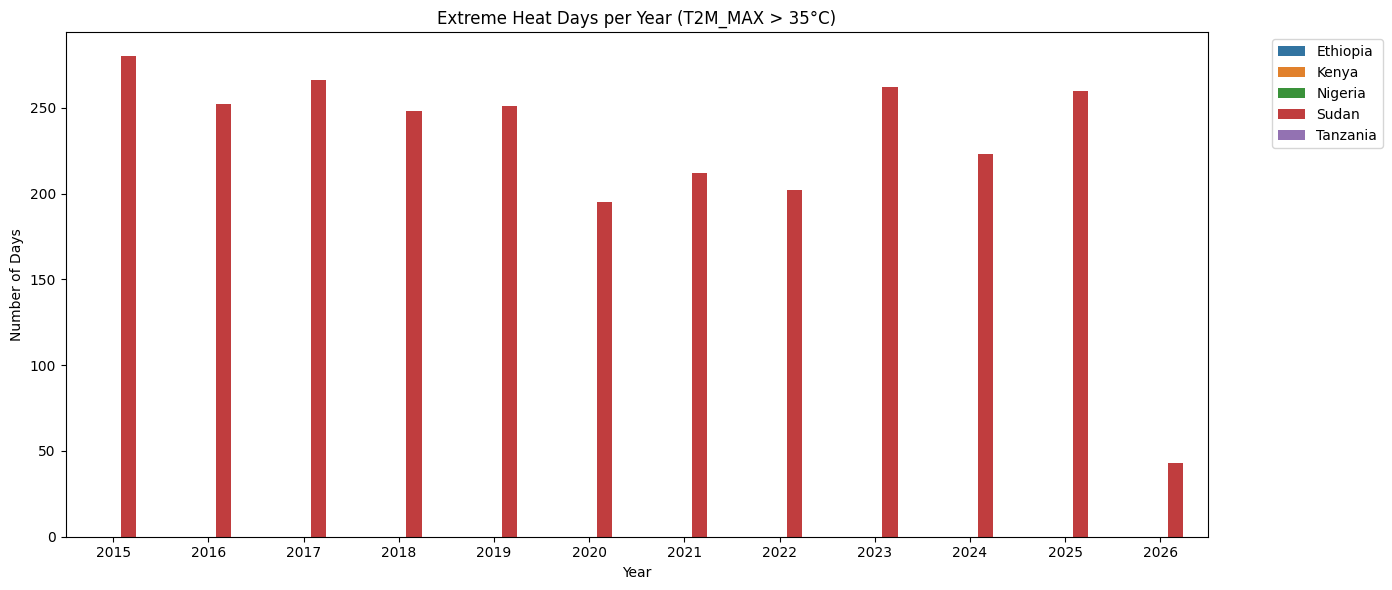

In [12]:
plt.figure(figsize=(14, 6))
sns.barplot(data=heat_days, x='Year', y='Extreme_Heat_Days', hue='Country')
plt.title('Extreme Heat Days per Year (T2M_MAX > 35°C)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Dry days for ALL countries

In [13]:
# Dry days (PRECTOTCORR < 1 mm)
combined['Dry_Day'] = combined['PRECTOTCORR'] < 1
dry_days = combined.groupby(['Country', combined['Date'].dt.year])['Dry_Day'].sum().reset_index()
dry_days.columns = ['Country', 'Year', 'Dry_Days']


print("Dry days per year for all countries:")
print(dry_days)

Dry days per year for all countries:
     Country  Year  Dry_Days
0   Ethiopia  2015       215
1   Ethiopia  2016       176
2   Ethiopia  2017       190
3   Ethiopia  2018       194
4   Ethiopia  2019       186
5   Ethiopia  2020       190
6   Ethiopia  2021       202
7   Ethiopia  2022       208
8   Ethiopia  2023       171
9   Ethiopia  2024       168
10  Ethiopia  2025       197
11  Ethiopia  2026        64
12     Kenya  2015       253
13     Kenya  2016       264
14     Kenya  2017       279
15     Kenya  2018       230
16     Kenya  2019       240
17     Kenya  2020       215
18     Kenya  2021       267
19     Kenya  2022       280
20     Kenya  2023       255
21     Kenya  2024       242
22     Kenya  2025       254
23     Kenya  2026        52
24   Nigeria  2015       159
25   Nigeria  2016       152
26   Nigeria  2017       137
27   Nigeria  2018       145
28   Nigeria  2019       109
29   Nigeria  2020       163
30   Nigeria  2021       143
31   Nigeria  2022       140
32   N

##### Bar chart of dry days by country

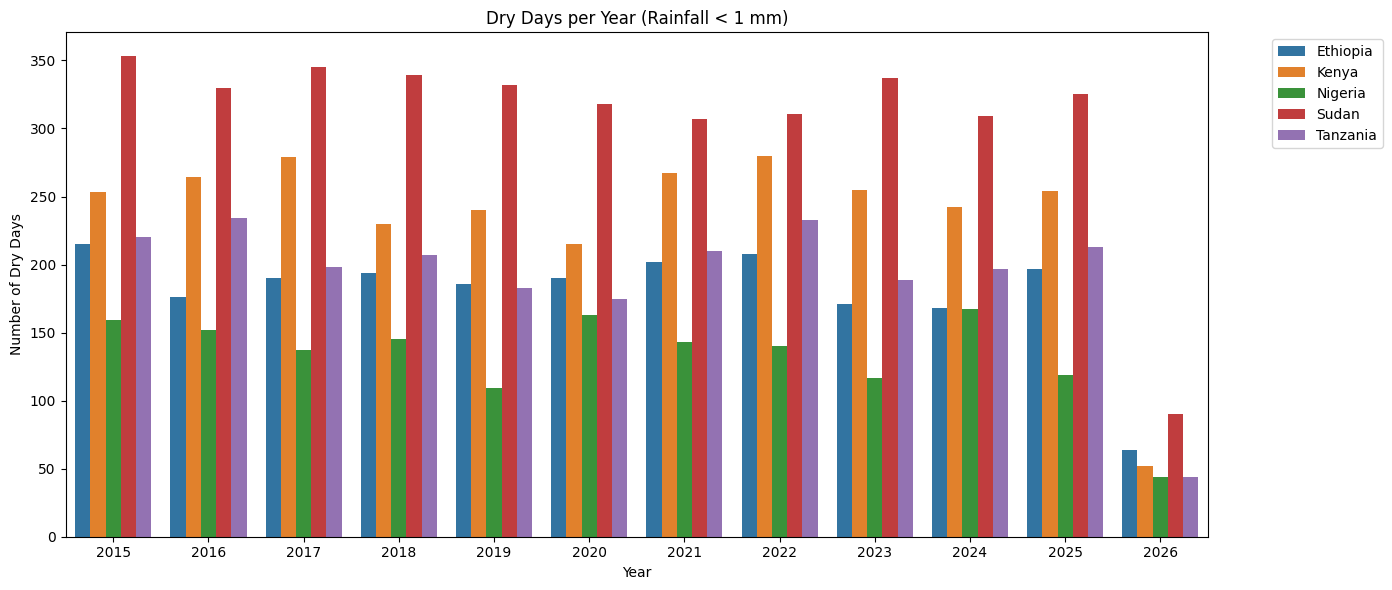

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(data=dry_days, x='Year', y='Dry_Days', hue='Country')
plt.title('Dry Days per Year (Rainfall < 1 mm)')
plt.xlabel('Year')
plt.ylabel('Number of Dry Days')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Extreme Event Observations

No extreme heat days (above 35°C) were recorded in any country between 2015-2026.

Sudan and Kenya have the most dry days (over 250 per year). 
Ethiopia has moderate dry days (around 190 per year).
Nigeria and Tanzania have the fewest dry days (around 150-200 per year).

Dry days have increased slightly in some countries but no strong trend.

##### ANOVA test to see if temperature differences between countries are statistically significant

In [15]:
from scipy.stats import f_oneway

ethiopia_temp = combined[combined['Country'] == 'Ethiopia']['T2M'].dropna()
kenya_temp = combined[combined['Country'] == 'Kenya']['T2M'].dropna()
nigeria_temp = combined[combined['Country'] == 'Nigeria']['T2M'].dropna()
sudan_temp = combined[combined['Country'] == 'Sudan']['T2M'].dropna()
tanzania_temp = combined[combined['Country'] == 'Tanzania']['T2M'].dropna()

f_stat, p_value = f_oneway(ethiopia_temp, kenya_temp, nigeria_temp, sudan_temp, tanzania_temp)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 18938.75
P-value: 0.0000


The p-value is 0.0000, which is less than 0.05. This means the temperature differences between countries are statistically significant. Sudan really is hotter than Ethiopia.

##### Climate Vulnerability Ranking (1 = most vulnerable, 5 = least vulnerable)

In [16]:
vulnerability_data = {
    'Rank': [1, 2, 3, 4, 5],
    'Country': ['Sudan', 'Kenya', 'Nigeria', 'Tanzania', 'Ethiopia'],
    'Avg Temp (°C)': [28.8, 20.4, 26.7, 26.8, 16.1],
    'Avg Rain (mm)': [0.6, 1.5, 4.2, 3.7, 3.6],
    'Dry Days/Year': ['Very High (320+)', 'High (260+)', 'Medium (180)', 'Medium (190)', 'Medium (190)'],
    'Why Vulnerable': ['Hottest, driest', 'Many dry days', 'High rain variability', 'Moderate heat', 'Coolest climate']
}
vuln_df = pd.DataFrame(vulnerability_data)
print(vuln_df.to_string(index=False))

 Rank  Country  Avg Temp (°C)  Avg Rain (mm)    Dry Days/Year        Why Vulnerable
    1    Sudan           28.8            0.6 Very High (320+)       Hottest, driest
    2    Kenya           20.4            1.5      High (260+)         Many dry days
    3  Nigeria           26.7            4.2     Medium (180) High rain variability
    4 Tanzania           26.8            3.7     Medium (190)         Moderate heat
    5 Ethiopia           16.1            3.6     Medium (190)       Coolest climate


### COP32 Key Observations 

**1. Which country is warming fastest and what does the trend suggest?**

Sudan is the hottest country with average temperature of 28.8°C. The data suggests Sudan faces the highest heat stress and most dry conditions, making climate adaptation urgent.

**2. Which country has the most unstable or extreme precipitation patterns?**

Nigeria and Tanzania have the highest rainfall variability. Their standard deviation for rainfall is over 7 mm, meaning some years have floods while others have drought. This makes farming very risky.

**3. What does extreme heat and drought frequency reveal about climate stress?**

Sudan and Kenya have over 250 dry days per year. Ethiopia has about 190 dry days. This means Sudan and Kenya face more water scarcity, affecting food security and health.

**4. How does Ethiopia's climate profile compare to its neighbors?**

Ethiopia is the coolest country at 16.1°C, while neighbors average 20-28°C. Ethiopia also has moderate rainfall (3.6 mm/day) and fewer dry days than Sudan and Kenya. Ethiopia is less vulnerable than its northern and eastern neighbors.

**5. Which country should Ethiopia champion for priority climate finance at COP32, and why does the data support this?**

Ethiopia should champion Sudan. The data shows Sudan has the highest temperatures (28.8°C), lowest rainfall (0.6 mm/day), and most dry days. Sudan is the most climate-vulnerable country in the region and needs urgent adaptation funding.